### Imports

In [23]:
import sys
from pathlib import Path

sys.path.append(str(Path("../../build-release").resolve()))

import mpcd_cpp as mpcd

import numpy as np
import matplotlib.pyplot as plt


### Parameters of Simulation

In [46]:
params = {
    "box": np.array([10.0, 10.0, 10.0]),

    # MPCD solvent
    "n_solvent": 5000,
    "solvent_mass": 1.0,
    "a": 1.0,
    "h": 0.1,
    "alpha": np.pi / 2,
    "kBT": 0.75,

    # Polymer
    "n_monomers": 30,
    "polymer_mass": 3.0,
    "bond_length": 0.25,
    "k_bond": 100.0,

    # MD
    "n_md_substeps": 500,
    "n_mpcd_steps": 10000,

    # Random seed
    "seed": 42,
}
dt_md = params["h"] / params["n_md_substeps"]

### Creation of a Polymer and a System

In [47]:
system = mpcd.System(
    params["n_solvent"],
    params["box"],
    params["a"],
    params["h"],
    params["solvent_mass"],
    params["kBT"],
    params["alpha"],
    params["seed"]
)

polymer = mpcd.Polymer(
    params["n_monomers"],
    params["box"],
    dt_md,
    params["bond_length"],
    params["polymer_mass"],
    params["k_bond"],
    params["kBT"],
    params["seed"] + 1
)

system.initPositionsUniform()
system.initVelocitiesNormal()

polymer.initPositionsRandomWalk()
polymer.initVelocitiesNormal()

### Simulation

In [57]:
samples = mpcd.runCoupled(
    system,
    polymer,
    params["n_mpcd_steps"],
    1,
    0,
    0
)

history = {}

history["step"] = np.asarray(samples.polymer.steps)

history["polymer_K"] = np.asarray(
    samples.polymer.kineticEnergy
)

history["polymer_U"] = np.asarray(
    samples.polymer.potentialEnergy
)

history["polymer_E"] = np.asarray(
    samples.polymer.totalEnergy
)

history["mean_bond_length"] = np.asarray(
    samples.polymer.averageBondLength
)

history["max_bond_length"] = np.asarray(
    samples.polymer.maxBondLength
)

history["solvent_K"] = np.asarray(
    samples.solvent.kineticEnergy
)

### Results
#### Polymer

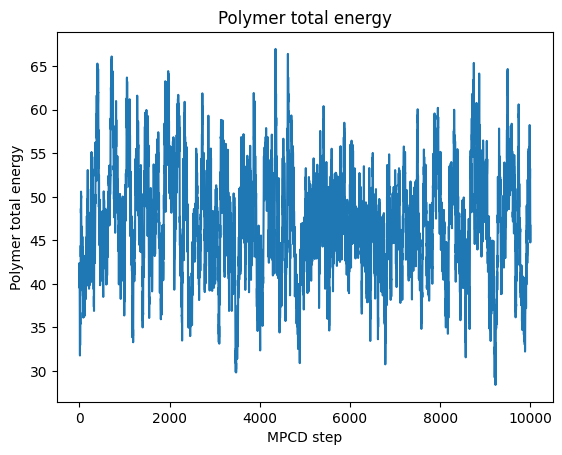

In [58]:
plt.figure()
plt.plot(history["step"], history["polymer_E"])
plt.xlabel("MPCD step")
plt.ylabel("Polymer total energy")
plt.title("Polymer total energy")
plt.show()

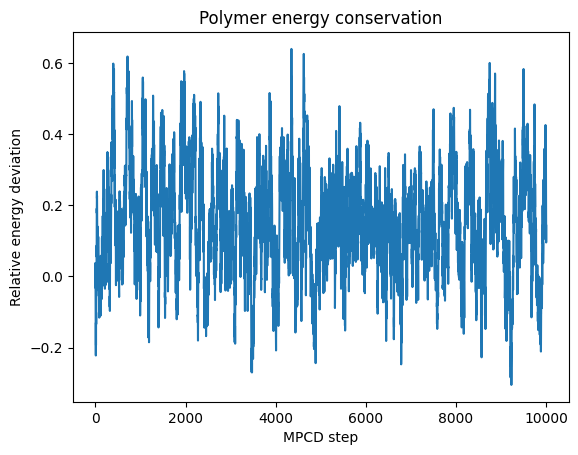

In [59]:
E0 = history["polymer_E"][0]

plt.figure()
plt.plot(history["step"], (history["polymer_E"] - E0) / abs(E0))
plt.xlabel("MPCD step")
plt.ylabel("Relative energy deviation")
plt.title("Polymer energy conservation")
plt.show()

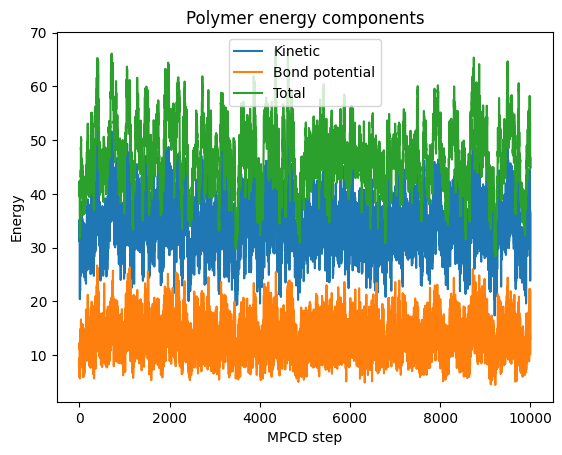

In [60]:
plt.figure()
plt.plot(history["step"], history["polymer_K"], label="Kinetic")
plt.plot(history["step"], history["polymer_U"], label="Bond potential")
plt.plot(history["step"], history["polymer_E"], label="Total")
plt.xlabel("MPCD step")
plt.ylabel("Energy")
plt.title("Polymer energy components")
plt.legend()
plt.show()

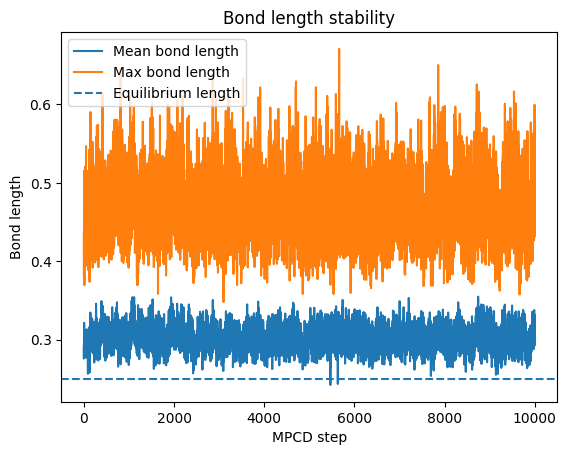

In [61]:
plt.figure()
plt.plot(history["step"], history["mean_bond_length"], label="Mean bond length")
plt.plot(history["step"], history["max_bond_length"], label="Max bond length")
plt.axhline(params["bond_length"], linestyle="--", label="Equilibrium length")
plt.xlabel("MPCD step")
plt.ylabel("Bond length")
plt.title("Bond length stability")
plt.legend()
plt.show()

### Polymer in 3D

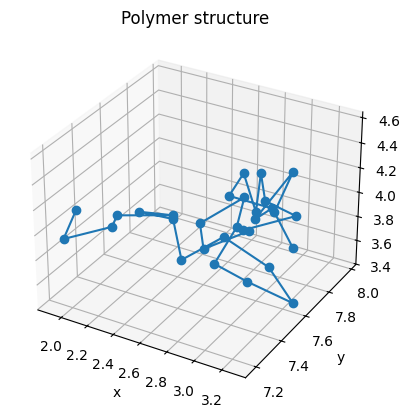

In [62]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

r = polymer.r

ax.plot(r[:, 0], r[:, 1], r[:, 2], marker="o")
#ax.set_xlim(0, params["box"][0])
#ax.set_ylim(0, params["box"][1])
#ax.set_zlim(0, params["box"][2])

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Polymer structure")

plt.show()

### System

In [63]:
history["total_E"] = history["solvent_K"] + history["polymer_E"]

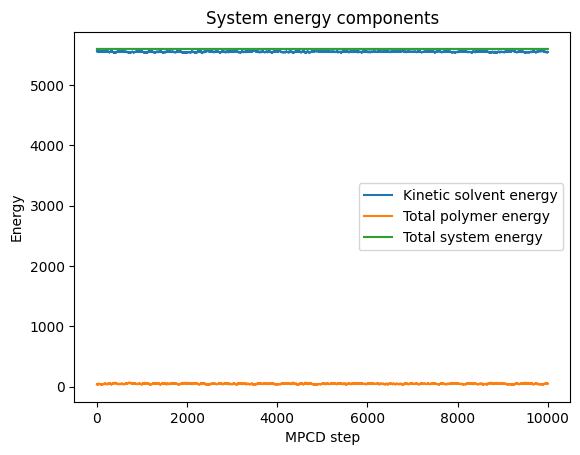

In [64]:
plt.figure()
plt.plot(history["step"], history["solvent_K"], label="Kinetic solvent energy")
plt.plot(history["step"], history["polymer_E"], label="Total polymer energy")
plt.plot(history["step"], history["total_E"], label="Total system energy")
plt.xlabel("MPCD step")
plt.ylabel("Energy")
plt.title("System energy components")
plt.legend()
plt.show()

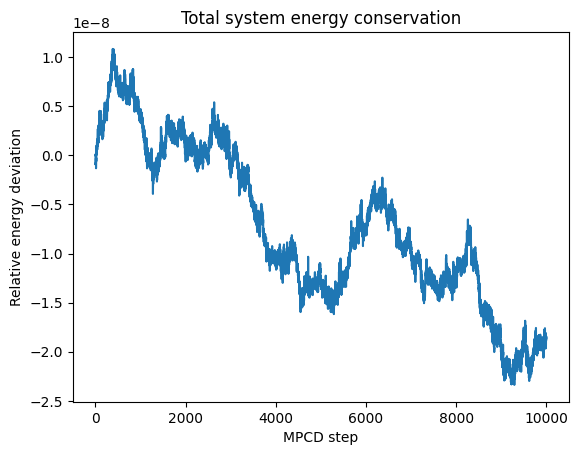

In [65]:
E0 = history["total_E"][0]

plt.figure()
plt.plot(history["step"], (history["total_E"] - E0) / abs(E0))
plt.xlabel("MPCD step")
plt.ylabel("Relative energy deviation")
plt.title("Total system energy conservation")
plt.show()